# 따릉이 거치대 수량(Available) 예측 — Weekday SARIMA/ARIMAX Pipeline

## 1. 라이브러리 로드 및 설정

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import jarque_bera, shapiro
from sklearn.metrics import mean_squared_error, mean_absolute_error


plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"


## 2. 설정값 및 데이터 로드

In [2]:
# 설정값
DATA_DIR        = Path("../data")   # interpolated_available_YYYYMM.csv
SEASONAL_PERIOD = 24             # 일일 계절 주기 (시간 단위 → S=24)
TEST_DAYS       = 30             # 마지막 30일을 test set으로 사용
TARGET_RENT_ID  = 2128           # 분석할 정류소 ID (정수형)


In [3]:
def load_available_csvs(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob("interpolated_available_*.csv"))
    if not files:
        raise FileNotFoundError(f"interpolated_available_*.csv 파일이 없습니다: {data_dir}")
    parts = [pd.read_csv(f) for f in files]
    df = pd.concat(parts, ignore_index=True)
    df["datetime"] = pd.to_datetime(
        df["DATE"].astype(str) + df["TIME"].astype(str).str.zfill(2),
        format="%Y%m%d%H"
    )
    df["RENT_ID"] = df["RENT_ID"].astype(int)
    return df

df_raw = load_available_csvs(DATA_DIR)
print(f"전체 데이터: {df_raw.shape}")
print(f"날짜 범위: {df_raw['datetime'].min()} ~ {df_raw['datetime'].max()}")
print(f"정류소 수: {df_raw['RENT_ID'].nunique()}개")
print(f"정류소 목록: {sorted(df_raw['RENT_ID'].unique())}")
df_raw.head()


전체 데이터: (381432, 5)
날짜 범위: 2023-01-01 00:00:00 ~ 2024-12-31 23:00:00
정류소 수: 23개
정류소 목록: [np.int64(2111), np.int64(2112), np.int64(2116), np.int64(2122), np.int64(2128), np.int64(2129), np.int64(2130), np.int64(2139), np.int64(2143), np.int64(2148), np.int64(2159), np.int64(2171), np.int64(2172), np.int64(2178), np.int64(2179), np.int64(2185), np.int64(2186), np.int64(2191), np.int64(2198), np.int64(2199), np.int64(3310), np.int64(3311), np.int64(3802)]


,DATE,TIME,RENT_ID,AVAILABLE,datetime
0,20230101,0,2111,0,2023-01-01
1,20230101,0,2112,5,2023-01-01
2,20230101,0,2116,2,2023-01-01
3,20230101,0,2122,1,2023-01-01
4,20230101,0,2128,5,2023-01-01


## 3. 데이터 전처리
`interpolated_available_YYYYMM.csv`는 이미 보간 완료된 데이터입니다.
- 결측치 없음 (선형 보간 적용 완료)
- 타겟 변수: `AVAILABLE` (시간대별 거치대 잔여 수량)
- 데이터 기간: 2023-01-01 ~ 2024-12-31
- 보간 전처리 관련은 `interpolation_available_report.md` 참고

In [4]:
def make_series(df: pd.DataFrame, rent_id: int) -> pd.Series:
    """
    특정 정류소의 시간별 AVAILABLE 시계열 생성
    interpolated_available_*.csv는 이미 보간 완료 → 결측 없음
    """
    sub = (
        df[df["RENT_ID"] == rent_id]
        .set_index("datetime")["AVAILABLE"]
        .sort_index()
    )
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq="h")
    sub = sub.reindex(full_idx)
    return sub.astype(float)

series = make_series(df_raw, TARGET_RENT_ID)
print(f"정류소 {TARGET_RENT_ID} 시계열: {len(series):,}시간")
print(f"기간: {series.index[0]} ~ {series.index[-1]}")
print(f"결측 수: {series.isna().sum()}")
series.head(10)


정류소 2128 시계열: 17,544시간
기간: 2023-01-01 00:00:00 ~ 2024-12-31 23:00:00
결측 수: 960


2023-01-01 00:00:00    5.0
2023-01-01 01:00:00    4.0
2023-01-01 02:00:00    4.0
2023-01-01 03:00:00    4.0
2023-01-01 04:00:00    4.0
2023-01-01 05:00:00    4.0
2023-01-01 06:00:00    6.0
2023-01-01 07:00:00    6.0
2023-01-01 08:00:00    5.0
2023-01-01 09:00:00    5.0
Freq: h, Name: AVAILABLE, dtype: float64

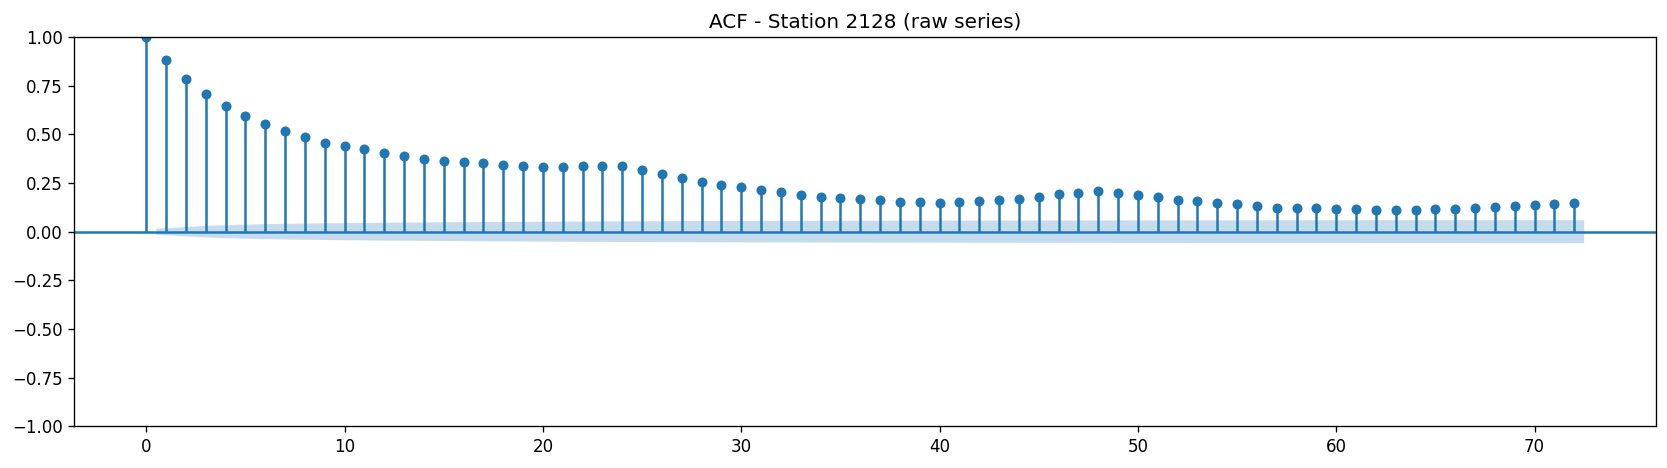

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(series.dropna(), lags=72, ax=ax,
         title=f"ACF - Station {TARGET_RENT_ID} (raw series)")
plt.tight_layout()
plt.show()

In [6]:
test_hours = TEST_DAYS * 24
train = series.iloc[:-test_hours]
test  = series.iloc[-test_hours:]

print(f"Train: {train.index[0]} ~ {train.index[-1]} ({len(train):,}시간)")
print(f"Test : {test.index[0]} ~ {test.index[-1]} ({len(test):,}시간)")


Train: 2023-01-01 00:00:00 ~ 2024-12-01 23:00:00 (16,824시간)
Test : 2024-12-02 00:00:00 ~ 2024-12-31 23:00:00 (720시간)


## 4. 정상성 검정 — ADF Test
- $H_0$: 단위근 존재 (non-stationary)
- $H_1$: 단위근 없음 (stationary)
- p-value < 0.05이면 정상성 확보

In [7]:
def adf_test(series: pd.Series, name: str = "", maxlag: int = 6):
    result = adfuller(series.dropna(), maxlag=maxlag, autolag="AIC")
    print(f"[ADF Test] {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical (1%) : {result[4]['1%']:.4f}")
    print(f"  Critical (5%) : {result[4]['5%']:.4f}")
    stationary = result[1] < 0.05
    print(f"  결론          : {'정상 (stationary)' if stationary else '비정상 → 차분 필요'}")
    return stationary

print("=" * 50)
is_stationary = adf_test(train, name=f"Station {TARGET_RENT_ID} (raw)")

if not is_stationary:
    print(f"\nS={SEASONAL_PERIOD} 계절 차분 후 재검정...")
    train_diff = train.diff(SEASONAL_PERIOD).dropna()
    print("=" * 50)
    adf_test(train_diff, name=f"Station {TARGET_RENT_ID} (after seasonal diff)")
else:
    train_diff = train


[ADF Test] Station 2128 (raw)
  ADF Statistic : -23.2045
  p-value       : 0.0000
  Critical (1%) : -3.4308
  Critical (5%) : -2.8617
  결론          : 정상 (stationary)


## 5. ACF / PACF 시각화
차수 후보 파악: ACF → MA 차수, PACF → AR 차수

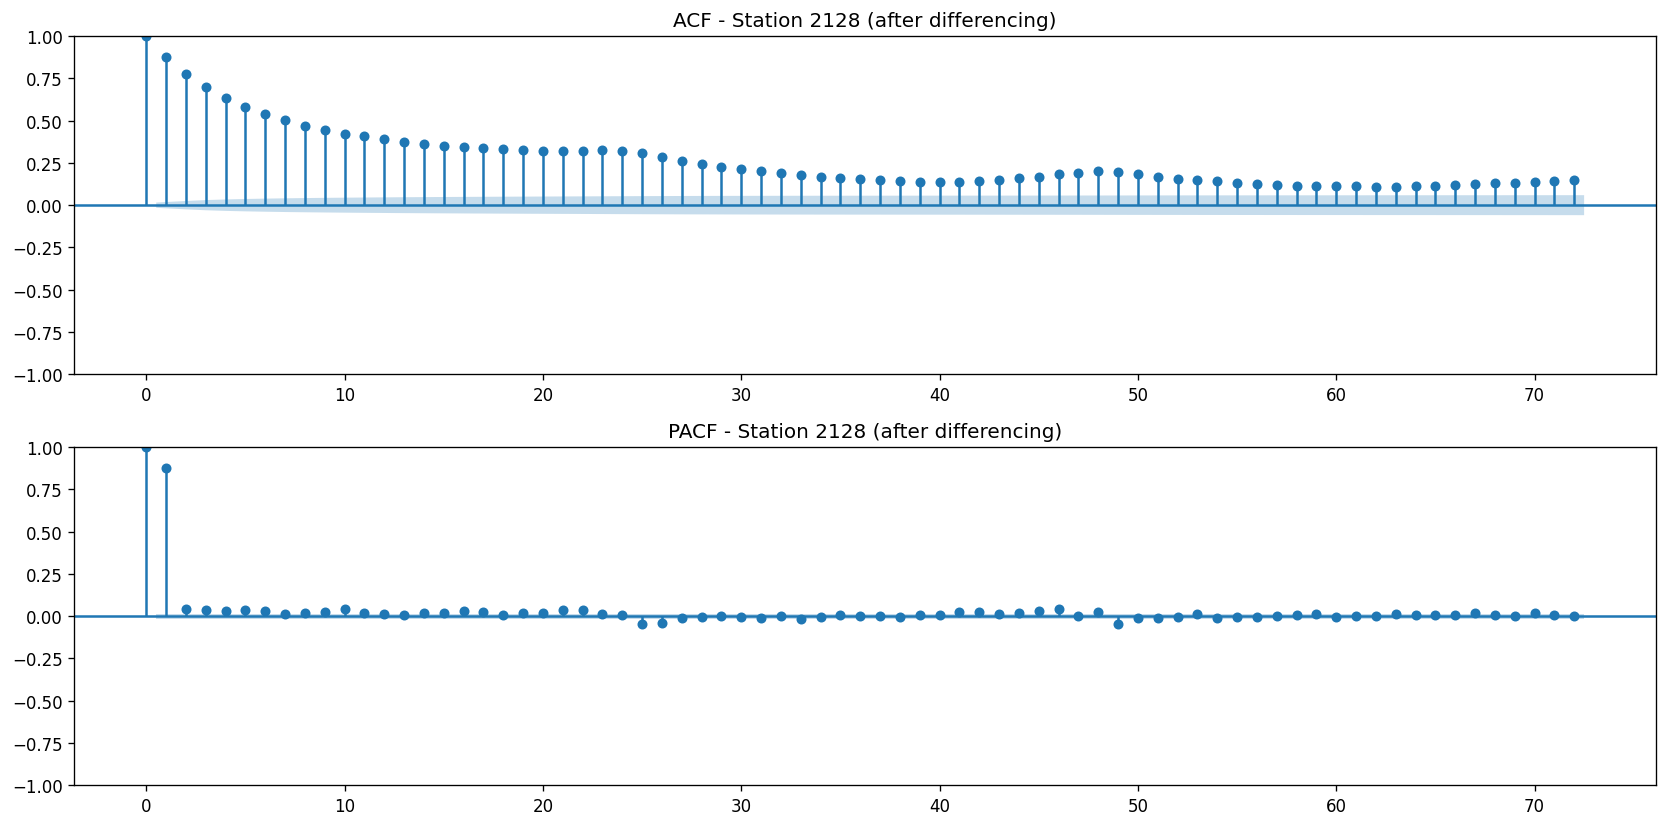

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_diff.dropna(), lags=72, ax=axes[0],
         title=f"ACF - Station {TARGET_RENT_ID} (after differencing)")
plot_pacf(train_diff.dropna(), lags=72, ax=axes[1],
          title=f"PACF - Station {TARGET_RENT_ID} (after differencing)")
plt.tight_layout()
plt.show()


## 6. SARIMA 모델 적합
`statsforecast AutoARIMA`로 AIC 기준 최적 차수 자동 선택 가능 

계절 주기 **S=24** (시간 단위 데이터 → 하루 주기)

1년치 데이터로 차수 추정

관련 코드 `available_auto_arima_weekday.py` 참고

In [9]:
# SARIMA 적합 — 서브셋 기준 최적 차수
order          = (1, 0, 2)
seasonal_order = (2, 1, 0, SEASONAL_PERIOD)
print(f"Using fixed order: ARIMA{order}x{seasonal_order}")

sarima_model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())


Using fixed order: ARIMA(1, 0, 2)x(2, 1, 0, 24)
                                      SARIMAX Results                                      
Dep. Variable:                           AVAILABLE   No. Observations:                16824
Model:             SARIMAX(1, 0, 2)x(2, 1, [], 24)   Log Likelihood              -24031.219
Date:                             Wed, 27 May 2026   AIC                          48074.438
Time:                                     18:44:21   BIC                          48120.795
Sample:                                 01-01-2023   HQIC                         48089.736
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8938      0.004    222.562      0.000    

## 7. ARIMAX 모델 적합
기상 데이터(기온, 강수여부)를 외생변수로 추가

| 외생변수 | 설명 |
|----------|------|
| `temp` | 시간별 기온(°C) |
| `rain_binary` | 1시간 강수량 ≥ 1mm 이면 1, 미만이면 0 |

결측 처리 규칙:
- 하절기(4~10월): 강수 기록 없으면 보수적으로 0
- 동절기(11~3월): 앞뒤 3시간 이내 관측값이 둘 다 1일 때만 1, 나머지 0

In [10]:
import sys
sys.path.insert(0, str(Path("..").resolve()))
from src.utils import load_rainfall_binary

# 기온 + 강수 이진변수 로드 (1mm 기준)
weather_df = load_rainfall_binary(DATA_DIR, threshold=1.0)

# train/test 인덱스에 맞게 정렬
exog_train = weather_df.reindex(train.index)[['temp', 'rain_binary']]
exog_test  = weather_df.reindex(test.index)[['temp', 'rain_binary']]

print(f'Weather range  : {weather_df.index.min().date()} ~ {weather_df.index.max().date()}')
print(f'Exog train shape: {exog_train.shape}')
print(f'Exog test  shape: {exog_test.shape}')
print(f'Missing in exog_train: {exog_train.isna().sum().to_dict()}')
print(f'Missing in exog_test : {exog_test.isna().sum().to_dict()}')
exog_train.head()

Weather range  : 2021-01-01 ~ 2025-12-31
Exog train shape: (16824, 2)
Exog test  shape: (720, 2)
Missing in exog_train: {'temp': 0, 'rain_binary': 0}
Missing in exog_test : {'temp': 0, 'rain_binary': 0}


,temp,rain_binary
2023-01-01 00:00:00,0.9,0
2023-01-01 01:00:00,1.5,0
2023-01-01 02:00:00,1.5,0
2023-01-01 03:00:00,1.6,0
2023-01-01 04:00:00,1.5,0


In [ ]:
# ARIMAX — 기온 + 강수여부 외생변수
arimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_fit = arimax_model.fit(disp=False)
print(arimax_fit.summary())

In [ ]:
# ARIMAX — 강수여부만 외생변수 (기온 제외)
exog_train_rain = exog_train[['rain_binary']]
exog_test_rain  = exog_test[['rain_binary']]

arimax_rain_model = SARIMAX(
    train,
    exog=exog_train_rain,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arimax_rain_fit = arimax_rain_model.fit(disp=False)
print(arimax_rain_fit.summary())

## 8. 잔차 진단
| 검정 | 귀무가설 |
|------|----------|
| Ljung-Box | 잔차에 자기상관 없음 (백색잡음) |
| Jarque-Bera | 잔차가 정규분포를 따름 |
| Shapiro-Wilk | 잔차가 정규분포를 따름 |

In [ ]:
def diagnose_residuals(fitted_model, model_name: str = "SARIMA"):
    residuals = pd.Series(fitted_model.resid.dropna())

    print(f"{'='*55}")
    print(f"  잔차 진단: {model_name}")
    print(f"{'='*55}")

    lb = acorr_ljungbox(residuals, lags=[10, 20, 48], return_df=True)
    print("\n[Ljung-Box Test] H0: 잔차에 자기상관 없음")
    print(lb[["lb_stat", "lb_pvalue"]].to_string())
    lb_pass = (lb["lb_pvalue"] > 0.05).all()
    print(f"  → {'백색잡음' if lb_pass else '자기상관 존재'}")

    jb_stat, jb_pval = jarque_bera(residuals)
    print(f"\n[Jarque-Bera Test] H0: 정규분포")
    print(f"  통계량={jb_stat:.4f}, p-value={jb_pval:.4f}")
    print(f"  → {'정규성 기각 불가' if jb_pval > 0.05 else '정규성 기각'}")

    sw_sample = residuals.sample(min(len(residuals), 5000), random_state=42)
    sw_stat, sw_pval = shapiro(sw_sample)
    print(f"\n[Shapiro-Wilk Test] H0: 정규분포")
    print(f"  통계량={sw_stat:.4f}, p-value={sw_pval:.4f}")
    print(f"  → {'정규성 기각 불가' if sw_pval > 0.05 else '정규성 기각'}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f"Residual Diagnostics - {model_name}", fontsize=13)
    axes[0, 0].plot(residuals.values, alpha=0.6)
    axes[0, 0].axhline(0, color="red", linestyle="--", alpha=0.5)
    axes[0, 0].set_title("Residual Time Series")
    axes[0, 1].hist(residuals, bins=50, edgecolor="black", alpha=0.7)
    axes[0, 1].set_title("Residual Histogram")
    plot_acf(residuals, lags=48, ax=axes[1, 0], title="Residual ACF")
    plot_pacf(residuals, lags=48, ax=axes[1, 1], title="Residual PACF")
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "lb_pass": lb_pass,
            "jb_pval": round(jb_pval, 4), "sw_pval": round(sw_pval, 4)}


  잔차 진단: SARIMA

[Ljung-Box Test] H0: 잔차에 자기상관 없음
      lb_stat  lb_pvalue
10   9.315262   0.502468
20  19.339060   0.499895
48  51.559189   0.336385
  → 백색잡음

[Jarque-Bera Test] H0: 정규분포
  통계량=20673.5993, p-value=0.0000
  → 정규성 기각

[Shapiro-Wilk Test] H0: 정규분포
  통계량=0.9404, p-value=0.0000
  → 정규성 기각


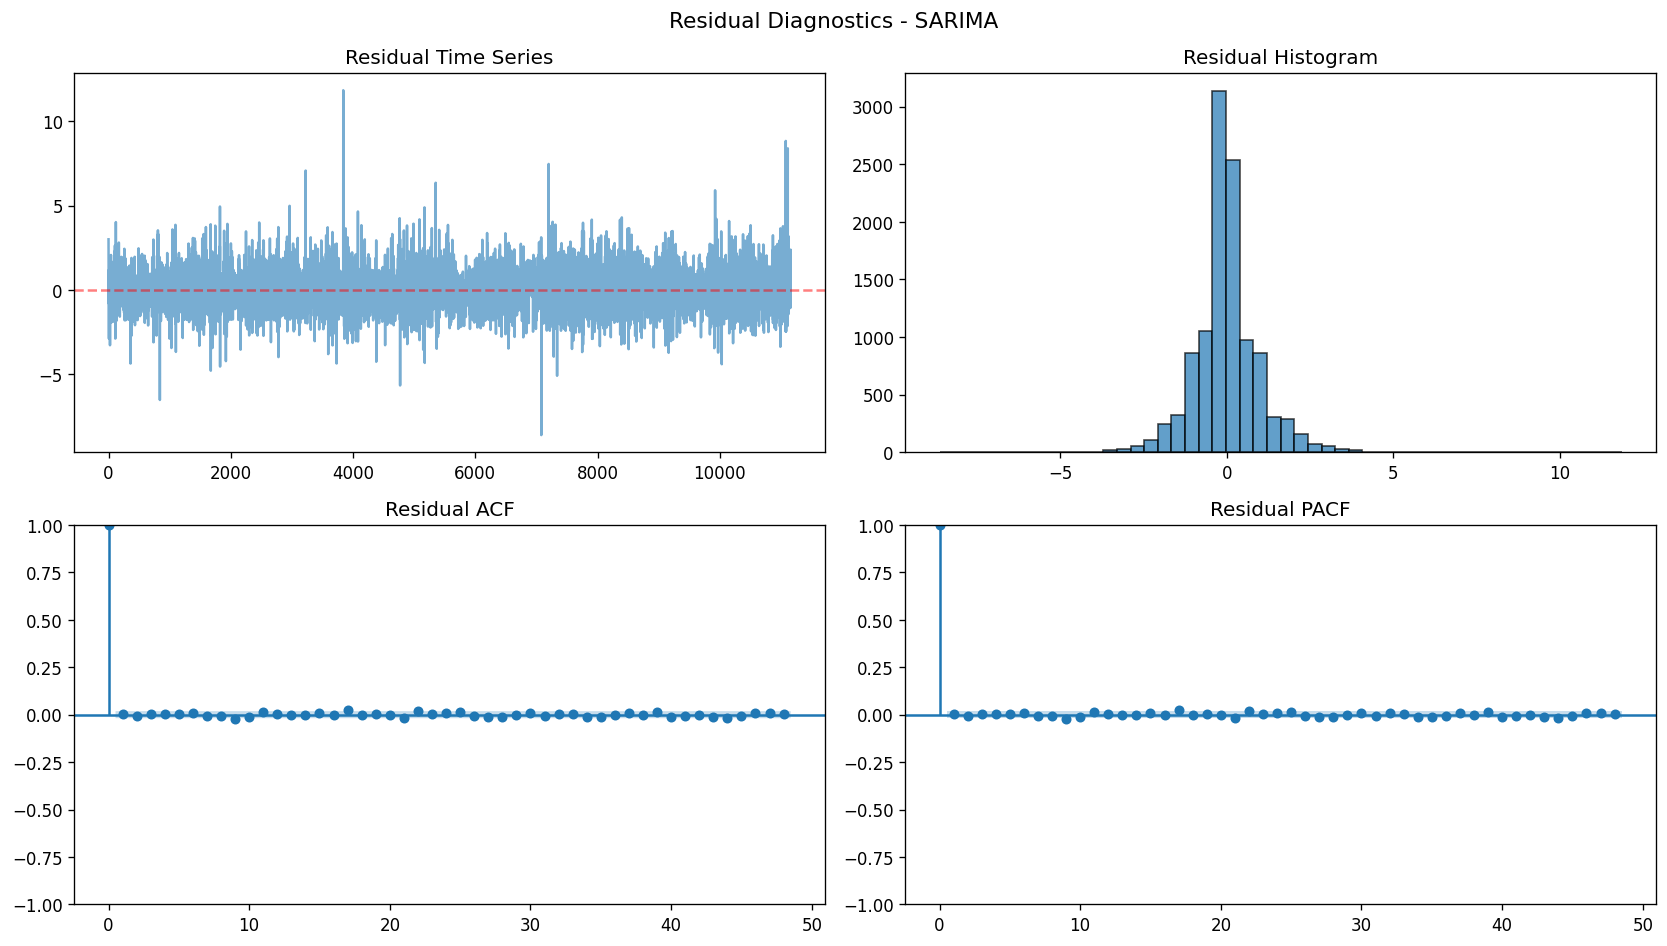

In [ ]:
diag_sarima = diagnose_residuals(sarima_fit, model_name='SARIMA')

In [ ]:
# ARIMAX (기온+강수) 잔차 진단
diag_arimax = diagnose_residuals(arimax_fit, model_name="ARIMAX (temp+rain)")

In [ ]:
# ARIMAX (강수만) 잔차 진단
diag_arimax_rain = diagnose_residuals(arimax_rain_fit, model_name="ARIMAX (rain only)")

## 9. 예측 성능 평가

### 평가 지표
| 지표 | 설명 | 비고 |
|------|------|------|
| **RMSE** | 기본 예측 정확도, 큰 오차에 민감 | 주요 지표 |
| **MAE** | 평균 절대 오차, 이상치 영향 적음 | 보조 지표 |
| **Asymmetric RMSE** | 과소예측에 $\alpha$배 패널티 | 조교님 권장 |
| **과소예측 비율** | $\hat{y} < y$ 인 비율 | 거치대 부족 위험도 |

### 비대칭 손실함수
$$L(\hat{y}, y) = \begin{cases} \alpha \cdot (\hat{y} - y)^2 & \text{if } \hat{y} < y \text{ (과소예측)} \\ (\hat{y} - y)^2 & \text{if } \hat{y} \geq y \text{ (과대예측)} \end{cases}$$

In [ ]:
def asymmetric_rmse(actual: pd.Series, forecast: pd.Series, alpha: float = 2.0) -> float:
    errors = forecast.values - actual.values
    loss = np.where(errors < 0, alpha * errors**2, errors**2)
    return float(np.sqrt(loss.mean()))


def evaluate_forecast(fitted_model, test: pd.Series,
                      model_name: str = "SARIMA",
                      exog_test: pd.DataFrame = None,
                      alpha: float = 2.0) -> dict:
    if exog_test is not None:
        forecast = fitted_model.forecast(steps=len(test), exog=exog_test)
    else:
        forecast = fitted_model.forecast(steps=len(test))

    forecast  = pd.Series(forecast.values, index=test.index)
    errors    = forecast - test

    rmse      = np.sqrt(mean_squared_error(test, forecast))
    mae       = mean_absolute_error(test, forecast)
    asym      = asymmetric_rmse(test, forecast, alpha=alpha)
    under_rate = (errors < 0).mean() * 100

    print(f"[{model_name}]")
    print(f"  RMSE              : {rmse:.3f}")
    print(f"  MAE               : {mae:.3f}")
    print(f"  Asymmetric RMSE   : {asym:.3f}  (alpha={alpha}, 과소예측 {alpha}배 패널티)")
    print(f"  과소예측 비율      : {under_rate:.1f}%  ← 거치대 부족 위험")

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(test.index, test.values, label="Actual (y)", alpha=0.7)
    axes[0].plot(forecast.index, forecast.values,
                 label=f"Forecast y-hat ({model_name})", linestyle="--", alpha=0.8)
    axes[0].set_title(f"Forecast vs Actual - {model_name}  "
                      f"[RMSE={rmse:.2f} | Asym.RMSE={asym:.2f}]")
    axes[0].legend()

    colors = ["red" if e < 0 else "steelblue" for e in errors]
    axes[1].bar(range(len(errors)), errors.values, color=colors, alpha=0.6, width=1)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title(f"Forecast Error (y-hat - y)  |  "
                      f"Red=Under, Blue=Over  |  Under-pred={under_rate:.1f}%")
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        f"Asym.RMSE(α={alpha})": round(asym, 3),
        "과소예측비율(%)": round(under_rate, 1),
    }


[SARIMA]
  RMSE              : 2.421
  MAE               : 1.828
  Asymmetric RMSE   : 1.873  (alpha=0.5, 과소예측 0.5배 패널티)
  과소예측 비율      : 46.8%  ← 거치대 부족 위험


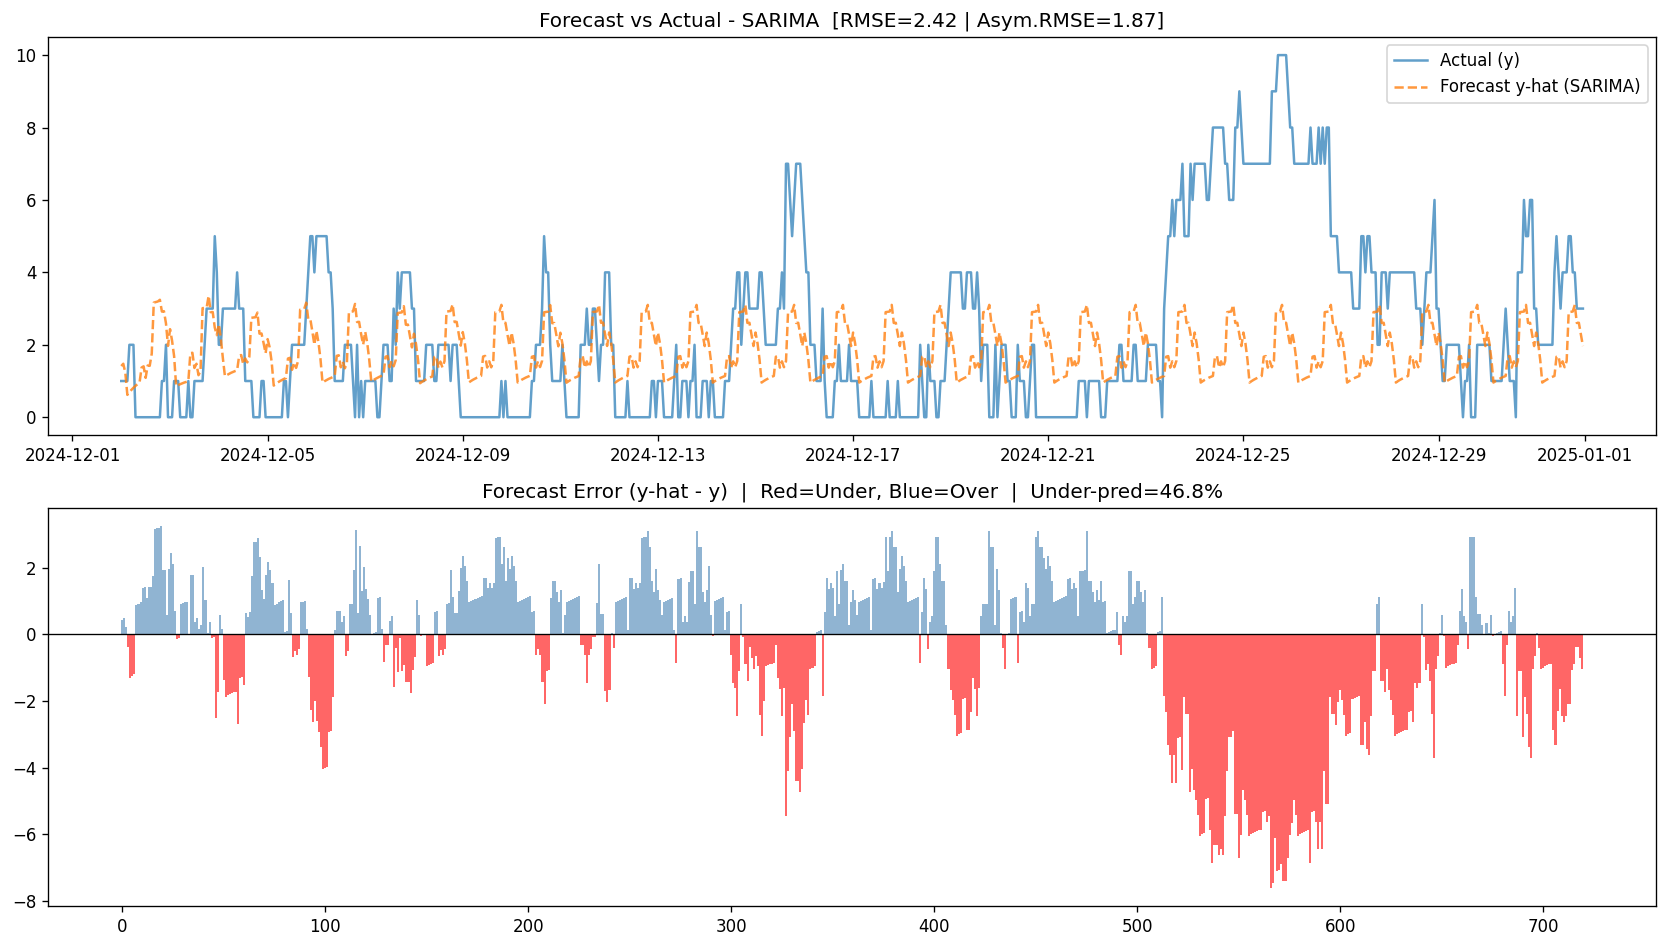

In [ ]:
ALPHA = 0.5
perf_sarima = evaluate_forecast(sarima_fit, test, model_name="SARIMA", alpha=ALPHA)

In [ ]:
perf_arimax = evaluate_forecast(
    arimax_fit, test,
    model_name="ARIMAX (temp+rain)",
    exog_test=exog_test,
    alpha=ALPHA
)

In [ ]:
perf_arimax_rain = evaluate_forecast(
    arimax_rain_fit, test,
    model_name="ARIMAX (rain only)",
    exog_test=exog_test_rain,
    alpha=ALPHA
)

## 10. 모델 성능 비교

In [ ]:
result_df = pd.DataFrame([perf_sarima, perf_arimax, perf_arimax_rain]).set_index("model")

print("\n" + "="*58)
print("          Model Performance Comparison")
print("="*58)
print(result_df.to_string())

asym_col = f"Asym.RMSE(α={ALPHA})"

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

result_df[["RMSE", "MAE"]].plot(
    kind="bar", ax=axes[0], title="RMSE / MAE Comparison", rot=0
)

result_df[[asym_col]].plot(
    kind="bar", ax=axes[1],
    title=f"Asymmetric RMSE (α={ALPHA})\n(under-pred penalized x{ALPHA})",
    rot=0, color="darkorange"
)

result_df[["과소예측비율(%)"]].rename(
    columns={"과소예측비율(%)": "Under-pred rate(%)"}
).plot(
    kind="bar", ax=axes[2],
    title="Under-prediction Rate\n(bike shortage risk)",
    rot=0, color="tomato"
)

plt.tight_layout()
plt.show()